<a href="https://colab.research.google.com/github/mailtobiswajit02-rgb/Python-Project/blob/main/StockpricePrediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Dataset : https://drive.google.com/file/d/1yluFUcEQVEziWpKwa95g9RO36hmhjB93/view?usp=sharing

The dataset consists the stock price value of netflix 2018 to 2022. The aim of this project is to predict the price as well as to forecast the price for next days.

Problem statement: The goal of this project is to analyze historical netflix stock price data and predict future stock prices using time series forecasting techniques.



# Step 1: Importing the libraries


In [ ]:
import warnings
warnings.filterwarnings("ignore")

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
plt.style.use("dark_background")

In [ ]:
from tqdm import tqdm
from scipy import stats
from prophet import Prophet
import statsmodels.api as sm
from itertools import product
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.graphics.tsaplots import plot_pacf
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.seasonal import seasonal_decompose

In [ ]:
df = pd.read_csv("/content/NFLX.csv")

In [ ]:
df

,Date,Open,High,Low,Close,Adj Close,Volume
0,2018-02-05,262.000000,267.899994,250.029999,254.259995,254.259995,11896100
1,2018-02-06,247.699997,266.700012,245.000000,265.720001,265.720001,12595800
2,2018-02-07,266.579987,272.450012,264.329987,264.559998,264.559998,8981500
3,2018-02-08,267.079987,267.619995,250.000000,250.100006,250.100006,9306700
4,2018-02-09,253.850006,255.800003,236.110001,249.470001,249.470001,16906900
...,...,...,...,...,...,...,...
1004,2022-01-31,401.970001,427.700012,398.200012,427.140015,427.140015,20047500
1005,2022-02-01,432.959991,458.480011,425.540009,457.130005,457.130005,22542300
1006,2022-02-02,448.250000,451.980011,426.480011,429.480011,429.480011,14346000
1007,2022-02-03,421.440002,429.260010,404.279999,405.600006,405.600006,9905200


Data Inspection

In [ ]:
df.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,2018-02-05,262.000000,267.899994,250.029999,254.259995,254.259995,11896100
1,2018-02-06,247.699997,266.700012,245.000000,265.720001,265.720001,12595800
2,2018-02-07,266.579987,272.450012,264.329987,264.559998,264.559998,8981500
3,2018-02-08,267.079987,267.619995,250.000000,250.100006,250.100006,9306700
4,2018-02-09,253.850006,255.800003,236.110001,249.470001,249.470001,16906900


In [ ]:
df.tail()

,Date,Open,High,Low,Close,Adj Close,Volume
1004,2022-01-31,401.970001,427.700012,398.200012,427.140015,427.140015,20047500
1005,2022-02-01,432.959991,458.480011,425.540009,457.130005,457.130005,22542300
1006,2022-02-02,448.250000,451.980011,426.480011,429.480011,429.480011,14346000
1007,2022-02-03,421.440002,429.260010,404.279999,405.600006,405.600006,9905200
1008,2022-02-04,407.309998,412.769989,396.640015,410.170013,410.170013,7782400


Step 3: Objectives to be followed

Fundamental analysis

This is the analysis that involves assessing the company's potential profitability by analyzing the current business environment and financial performance.

Technical analysis

This process involves studying the graphs and using the statistical data to understand and identify the patterns and trends in the stocks.

For this particular project, we would focusing more on to the technical part of the analysis.

*Dataset content*

*  Target: The calculation of profitnand loss is typically based on the closing price for the stock on a day. Therefore for the analysis purpose we will be considering the Adj Close as target variable.
* Open and Close: These are the prices of the stock at the start and the end of the day.
* Volume: The number of shares that has been traded in a day.

# Removing all the other columns

Since, we are aware that most of the problems are going to be solved using Adj Close column, hence we will be dropping the other columns rather than date.

In [ ]:
df = df.drop(['Open', 'High', 'Low', 'Close', 'Volume'], axis = 1)

In [ ]:
df.head()

,Date,Adj Close
0,2018-02-05,254.259995
1,2018-02-06,265.720001
2,2018-02-07,264.559998
3,2018-02-08,250.100006
4,2018-02-09,249.470001


Step 4: Technical Analysis

Collect/Gather the data together

In [ ]:
df = df.groupby("Date")['Adj Close'].sum().reset_index()

In [ ]:
df.head()

,Date,Adj Close
0,2018-02-05,254.259995
1,2018-02-06,265.720001
2,2018-02-07,264.559998
3,2018-02-08,250.100006
4,2018-02-09,249.470001


Convert the date column into datetime format

In [ ]:
df['Date'] = pd.to_datetime(df['Date'])

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1009 entries, 0 to 1008
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Date       1009 non-null   datetime64[ns]
 1   Adj Close  1009 non-null   float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 15.9 KB


Set the datetime column into index

In [ ]:
df = df.set_index(['Date'])

In [ ]:
df.head()

,Adj Close
Date,
2018-02-05,254.259995
2018-02-06,265.720001
2018-02-07,264.559998
2018-02-08,250.100006
2018-02-09,249.470001


we wanted to understand the behaviour of the target variable

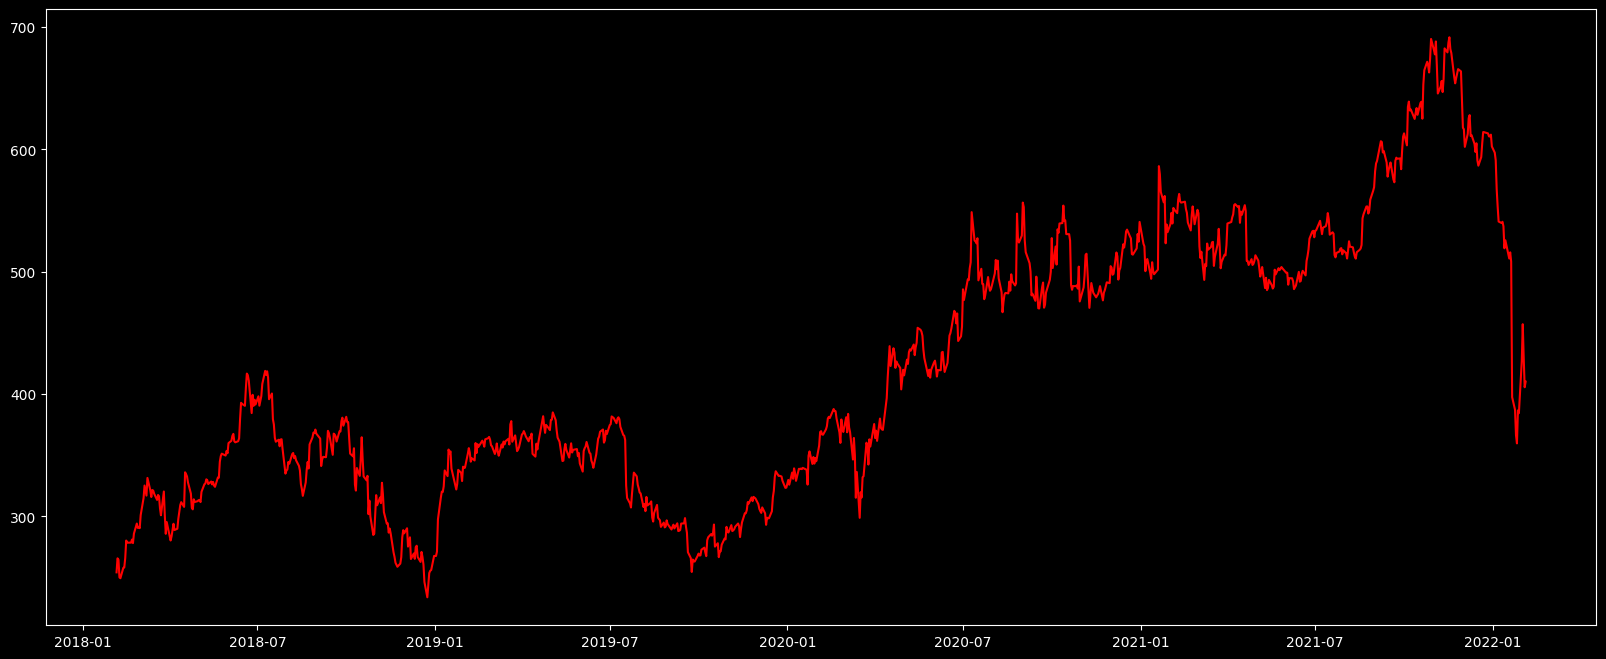

In [ ]:
plt.figure(figsize=(20,8))
plt.plot(df,color='red')
plt.show()

Looking at the data we can clearly say that after the year 2020, we have got a very great upward trend and having a sharp decline in the recent date like Nov, 2021

Step 5: Check for stationarity

Implementing ADFuller

In [ ]:
results = adfuller(df)

In [ ]:
results

(np.float64(-1.8125906878289955),
 np.float64(0.3742289256820759),
 6,
 1002,
 {'1%': np.float64(-3.436893045520188),
  '5%': np.float64(-2.8644287878535146),
  '10%': np.float64(-2.568308127138936)},
 np.float64(7545.926742057859))

In [ ]:
print(f"""ADF Stats: {results[0]}
      \nP-Value: {results[1]}
      \nLags Used: {results[2]}""")

ADF Stats: -1.8125906878289955
      
P-Value: 0.3742289256820759
      
Lags Used: 6


Lags used: how many previous lagged values the adf test used internally while checking whether time series is stationary.

In [ ]:
if results[1] > 0.05:
  print("The data is not stationary")
else:
  print("The data is stationary")

The data is not stationary


Step 6: Achieving stationarity

Differencing

In [ ]:
diff1 = df - df.shift(1)

In [ ]:
diff1 = diff1.dropna()

Let's check again for stationarity

In [ ]:
results = adfuller(diff1)

In [ ]:
if results[1] > 0.05:
  print("The data is not stationary")
else:
  print("the data is stationary")

the data is stationary


# Visualize the results

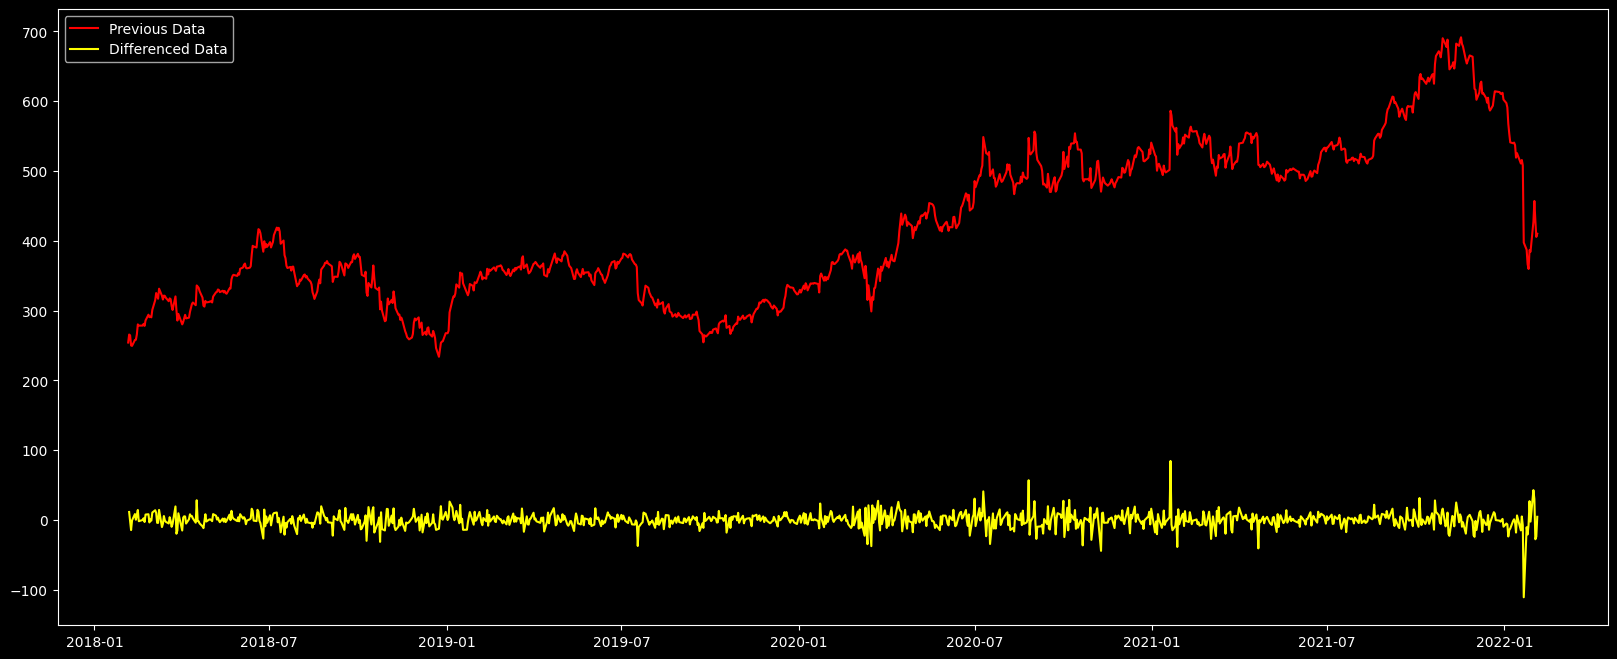

In [ ]:
plt.figure(figsize=(20,8))
plt.plot(df,color='red',label='Previous Data')
plt.plot(diff1,color='yellow',label='Differenced Data')
plt.legend()
plt.show()

*  With reference to the previous data, we can easily observe that there was a lot of hinderance in the previous data, as we can clearly observe the change in the mean and variance over the period of time.

*  If we consider the new data (differenced data), we can clearly observe that the constant change is no more there in the data.

In [ ]:
# Good morning everyone!!!!!
# Quickly Join in , We will be starting at 7:06one!!!!!$0 am sharp......

In [ ]:
# Seasonal Decomoposition


In [ ]:
decompose = seasonal_deco


In [ ]:
decompose = seasonal_decompose(x=diff1, period = 30
)

In [ ]:
decompose = seasonal_decompose(x=diff1, period = 30)

In [ ]:
trend = decompose.trend
seasonality = decompose.seasonal
noise = decompose.noise

AttributeError: 'DecomposeResult' object has no attribute 'noise'

In [ ]:
trend = decompose.trend
seasonality = decompose.seasonal
noise = decompose.resid

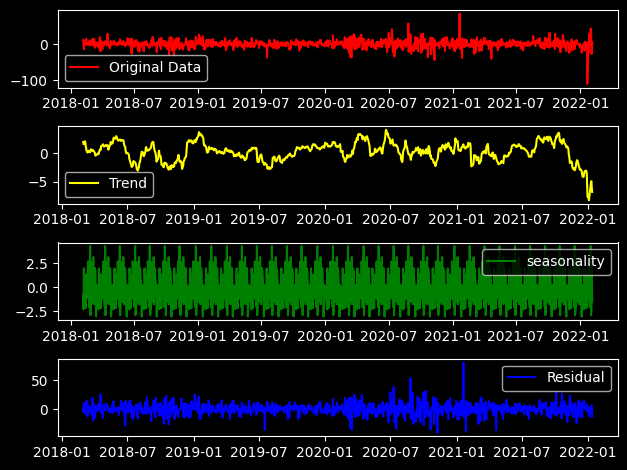

In [ ]:
plt.subplot(411)
plt.plot(diff1, label = 'Original Data', color = 'red')
plt.legend()


plt.subplot(412)
plt.plot(trend, label = 'Trend', color = 'yellow')
plt.legend()

plt.subplot(413)
plt.plot(seasonality, label = 'seasonality', color = 'green')
plt.legend()


plt.subplot(414)
plt.plot(noise,label= "Residual",color = 'blue')
plt.legend()
plt.tight_layout()

In [ ]:
# Finding the orders of the model

diff1.columns

Index(['Adj Close'], dtype='object')

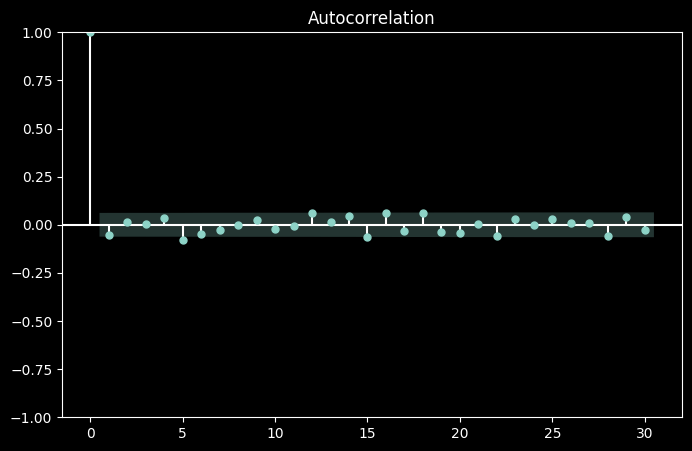

In [ ]:
fig, ax = plt.subplots(figsize = (8,5))
plot_acf(diff1["Adj Close"], ax = ax, lags = 30)
plt.show()

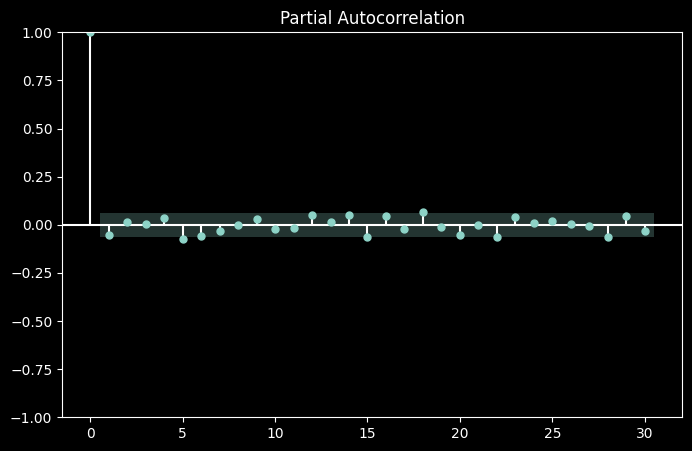

In [ ]:
fig, ax = plt.subplots(figsize = (8,5))
plot_pacf(diff1["Adj Close"], ax = ax , lags = 30)
plt.show()

In [ ]:
# Itertools approach

p = range(0,8,1)
d = 1
q = range(0,8,1)

In [ ]:
parameter_list = product(p,q)

In [ ]:
parameters = list(par
)

In [ ]:
paramters = list(parameter_list)

In [ ]:
paramters

[(0, 0),
 (0, 1),
 (0, 2),
 (0, 3),
 (0, 4),
 (0, 5),
 (0, 6),
 (0, 7),
 (1, 0),
 (1, 1),
 (1, 2),
 (1, 3),
 (1, 4),
 (1, 5),
 (1, 6),
 (1, 7),
 (2, 0),
 (2, 1),
 (2, 2),
 (2, 3),
 (2, 4),
 (2, 5),
 (2, 6),
 (2, 7),
 (3, 0),
 (3, 1),
 (3, 2),
 (3, 3),
 (3, 4),
 (3, 5),
 (3, 6),
 (3, 7),
 (4, 0),
 (4, 1),
 (4, 2),
 (4, 3),
 (4, 4),
 (4, 5),
 (4, 6),
 (4, 7),
 (5, 0),
 (5, 1),
 (5, 2),
 (5, 3),
 (5, 4),
 (5, 5),
 (5, 6),
 (5, 7),
 (6, 0),
 (6, 1),
 (6, 2),
 (6, 3),
 (6, 4),
 (6, 5),
 (6, 6),
 (6, 7),
 (7, 0),
 (7, 1),
 (7, 2),
 (7, 3),
 (7, 4),
 (7, 5),
 (7, 6),
 (7, 7)]

In [ ]:
order_list = []

In [ ]:
# We will start evaluating each order one by one

for x in paramters:
  comb = list(x)

  comb.insert(1,d)

  comb = tuple(comb)

  order_list.append(comb)

In [ ]:
order_list[:10]

[(0, 1, 0),
 (0, 1, 1),
 (0, 1, 2),
 (0, 1, 3),
 (0, 1, 4),
 (0, 1, 5),
 (0, 1, 6),
 (0, 1, 7),
 (1, 1, 0),
 (1, 1, 1)]

In [ ]:
# Sarimax

def optimize_sarimax(data,order_list):
  results = []

  for x in tqdm(order_list, desc = "Fitting SARIMA model"):
    try:


In [ ]:
# Sarimax

def optimize_sarimax(data,order
                     )

In [ ]:
def optimize_sarimax(data,order_list)


In [ ]:
def optimize_sarimax(data,order_list):
  results = []

  for x in tqdm(order_list, desc = "Fitting SARIMA Model"):
    try:
      model = SARIMAX(data,order = x,simple_differencing = False).fit(display=False)
    except:
      continue

    # AIC
    aic = model.aic
    results.append([x,aic])

  results_df = pd.DataFrame(results,columns = ["(P,D,Q)", "AIC "])

  return results_df

In [ ]:
results_df = optimize_sarimax(df["Adj Close"],order_list)

Fitting SARIMA Model:   0%|          | 0/64 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
Fitting SARIMA Model:   2%|▏         | 1/64 [00:00<00:07,  8.69it/s]/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provide

In [ ]:
#

In [ ]:
# Predictions

best_order = results_df.loc[0, "(P,D,Q)"]

model = SARIMAX(df["Adj Close"],order = best_order,simple_differencing= False).fit(disp=False)
forecast = model.get_forecast(steps = 30)
predicted_values = forecast.predicted_mean
print(predicted_values)

1009    410.170013
1010    410.170013
1011    410.170013
1012    410.170013
1013    410.170013
1014    410.170013
1015    410.170013
1016    410.170013
1017    410.170013
1018    410.170013
1019    410.170013
1020    410.170013
1021    410.170013
1022    410.170013
1023    410.170013
1024    410.170013
1025    410.170013
1026    410.170013
1027    410.170013
1028    410.170013
1029    410.170013
1030    410.170013
1031    410.170013
1032    410.170013
1033    410.170013
1034    410.170013
1035    410.170013
1036    410.170013
1037    410.170013
1038    410.170013
Name: predicted_mean, dtype: float64


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


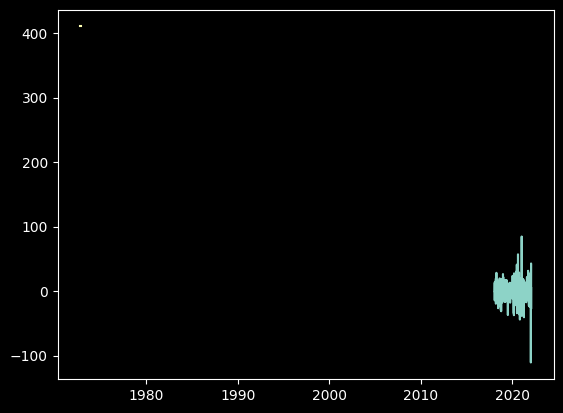

In [ ]:
plt.plot(diff1)
plt.plot(predicted_values)

In [ ]:
best_order

(0, 1, 0)

In [ ]:
# ARIMA

model = ARIMA(df["Adj Close"],order = best_order)
results = model.fit()
results.summary()

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:              Adj Close   No. Observations:                 1009
Model:                 ARIMA(0, 1, 0)   Log Likelihood               -3851.903
Date:                Fri, 26 Jun 2026   AIC                           7705.806
Time:                        03:01:15   BIC                           7710.722
Sample:                             0   HQIC                          7707.674
                               - 1009                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
sigma2       122.0953      1.889     64.647      0.000     118.394     125.797
===================================================================================
Ljung-Box (L1) (Q):                   2.64   Jarque-Bera (JB):              9050.50
Prob(Q):                              0.10   Prob(JB):                         0.00
Heteroskedasticity (H):               2.27   Skew:                            -0.63
Prob(H) (two-sided):                  0.00   Kurtosis:                        17.63
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [ ]:
df["Prediction ARIMA"] = results.predict(start = 1, end = 1008)

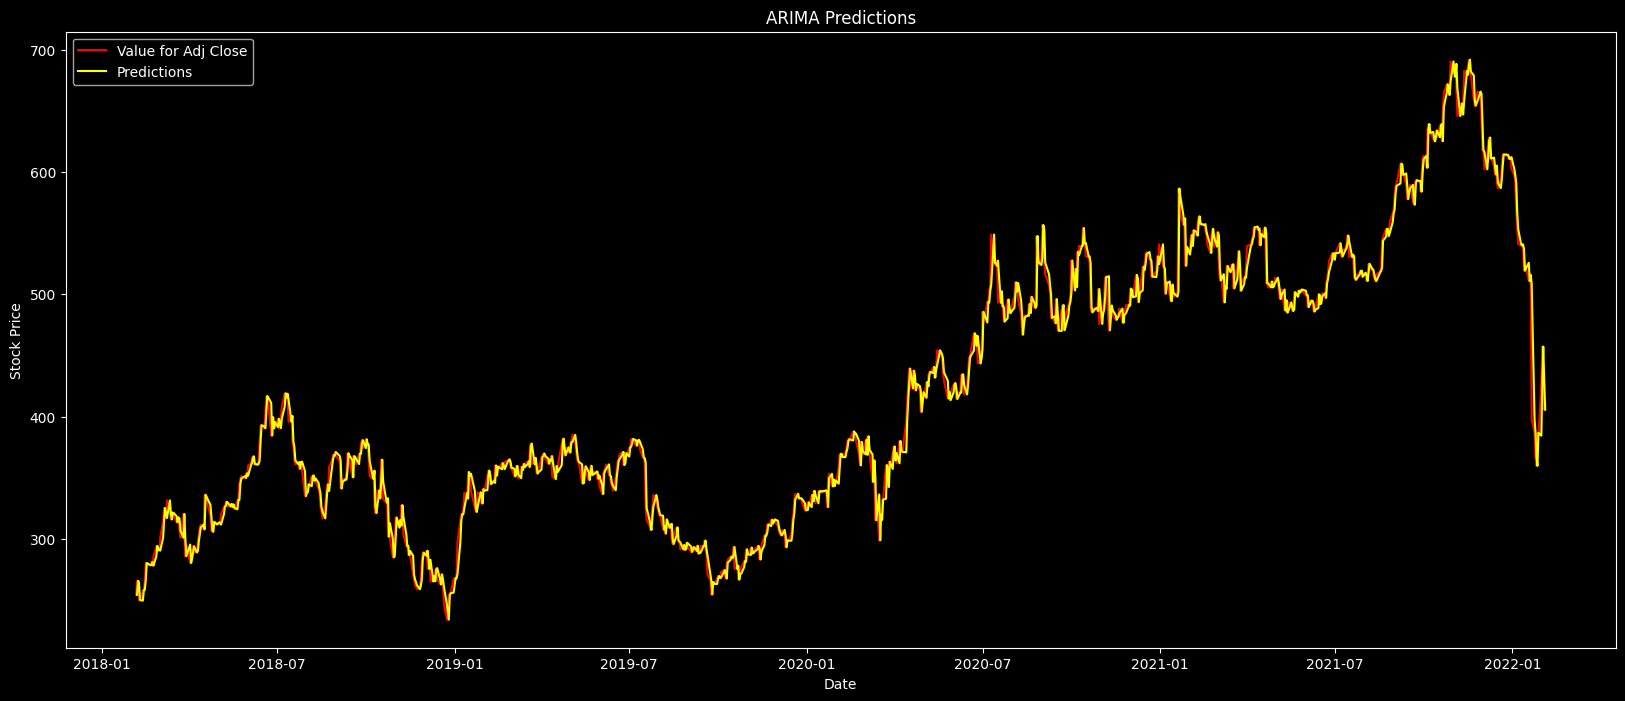

In [ ]:
plt.figure(figsize = (20,8))
plt.plot(df["Adj Close"], color = "red", label = "Value for Adj Close")
plt.plot(df["Prediction ARIMA"],color = "yellow", label = "Predictions")
plt.xlabel("Date")
plt.ylabel("Stock Price")
plt.title("ARIMA Predictions")
plt.legend()
plt.show()

In [ ]:
df.head()

,Adj Close,Prediction ARIMA
Date,,
2018-02-05,254.259995,NaN
2018-02-06,265.720001,254.259995
2018-02-07,264.559998,265.720001
2018-02-08,250.100006,264.559998
2018-02-09,249.470001,250.100006


In [ ]:
# Prophet


In [ ]:
df_prophet = df.reset_index()

df_prophet = df_prophet[["Date","Adj Close"]]

In [ ]:
df_prophet.head()

,Date,Adj Close
0,2018-02-05,254.259995
1,2018-02-06,265.720001
2,2018-02-07,264.559998
3,2018-02-08,250.100006
4,2018-02-09,249.470001


In [ ]:
# Prophet alwars accepts the data in two particular columns ds , y

In [ ]:
df_prophet = df_prophet.rename(columns = {"Date": "ds", "Adj Close" : "y"})

In [ ]:
model = Prophet()

In [ ]:
model.fit(df_prophet)

INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


In [ ]:
# Prediction

future = model.make_future_dataframe(periods = 365)

In [ ]:
forecast = model.predict(future)

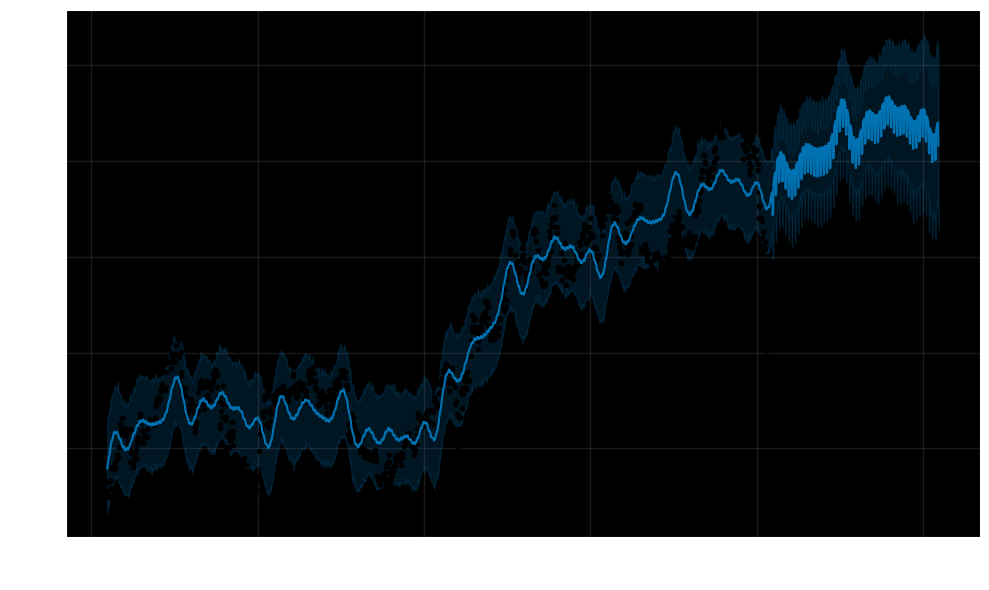

In [ ]:
# Visualiza

model.plot(forecast)
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

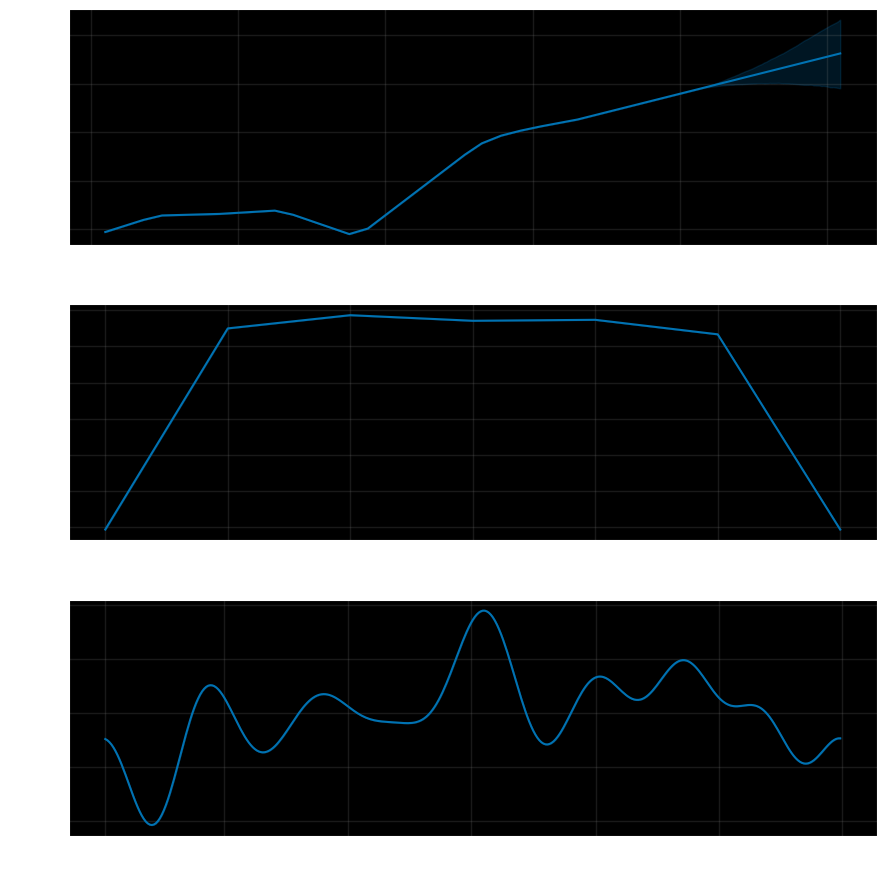

In [ ]:
model.plot_components(forecast)
plt.show